In [2]:
## Hippo target selection: AP-1, STAT, and TEA motif filtering

In [3]:
import os, pickle, numpy as np
from collections import Counter

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'

# Load the eigen analysis library
with open(os.path.join(REPO, 'genomic_targets', 'data', 'eigen_analysis.pkl'), 'rb') as f:
    cached = pickle.load(f)

print('Keys in pkl:', list(cached.keys()))

Keys in pkl: ['motif_hits', 'eigen_results', 'ei1_vecs', 'ei2_vecs', 'ei1_var', 'ei1_evals', 'ei2_evals', 'ratio', 'corrs', 'has_motifs_both', 'predictions']


In [4]:
motif_hits = cached['motif_hits']   # dict: cell_type -> list of lists (per sequence)
ratio      = cached['ratio']        # EI1/EI2 eigenvalue ratio per sequence
corrs      = cached['corrs']        # importance correlation (r) per sequence
has_motifs_both = cached['has_motifs_both']

n_seqs = len(ratio)
print(f'Total sequences: {n_seqs}')
print(f'With motifs in both cell lines: {has_motifs_both.sum()} ({has_motifs_both.mean():.1%})')

Total sequences: 56975
With motifs in both cell lines: 13561 (23.8%)


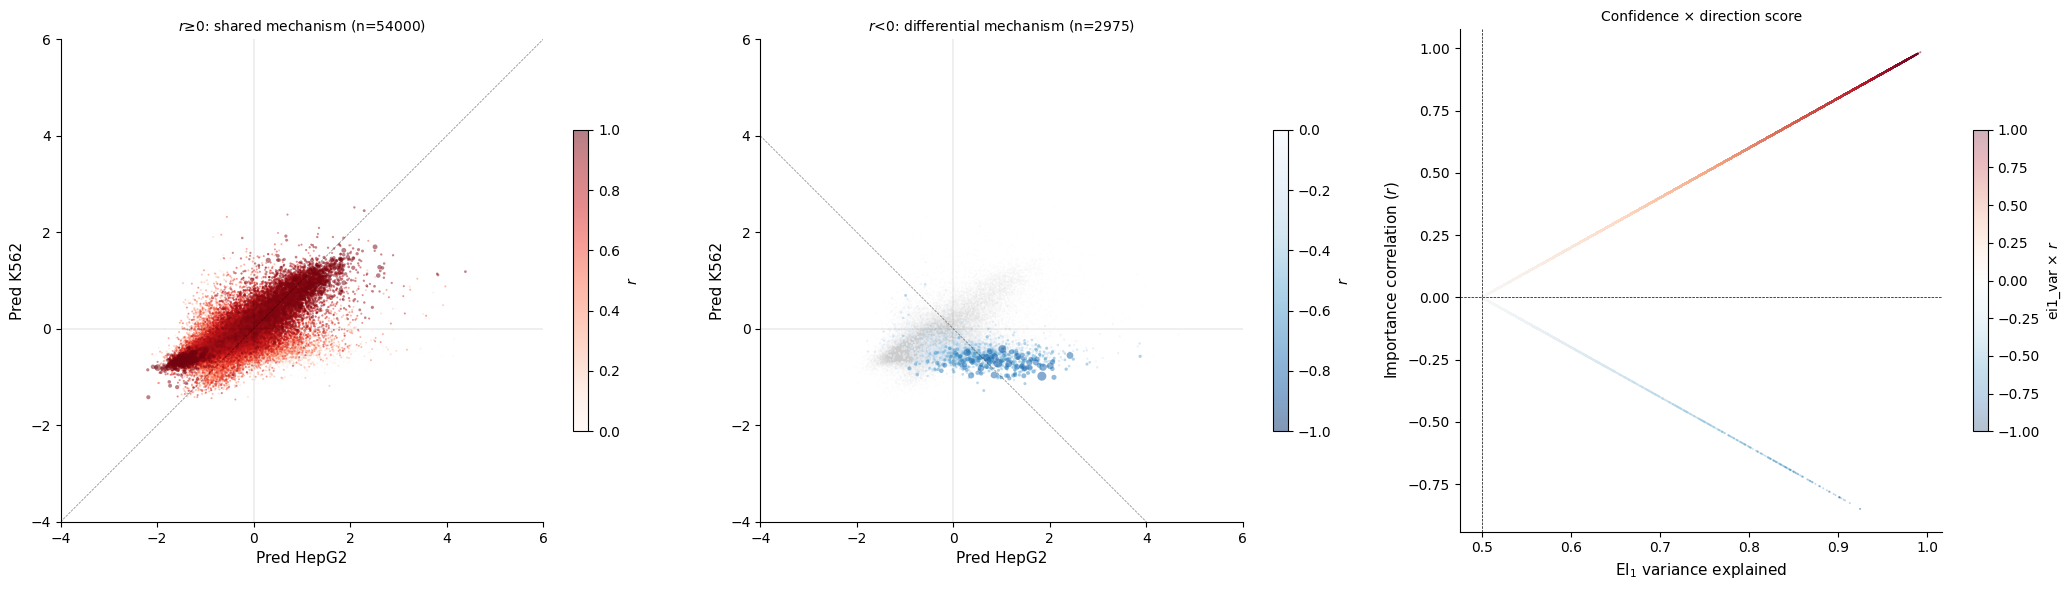

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

predictions = cached['predictions']
ei1_var = cached['ei1_var']
pos = corrs >= 0
neg = corrs < 0

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
lims = [-4, 6]

# Left: r>=0, neg grayed
neg_order = np.where(neg)[0][np.argsort(ratio[neg])]
ax1.scatter(predictions['HepG2'][neg_order], predictions['K562'][neg_order],
            s=1, alpha=0.05, c='#cccccc', edgecolors='none', rasterized=True)
pos_order = np.where(pos)[0][np.argsort(np.abs(corrs[pos]))]
pos_sizes = 2 + 40 * (ratio[pos_order] / np.clip(ratio[pos_order].max(), 1, None))**2
sc1 = ax1.scatter(predictions['HepG2'][pos_order], predictions['K562'][pos_order],
                  s=pos_sizes, alpha=0.5, c=corrs[pos_order], cmap='Reds',
                  vmin=0, vmax=1, edgecolors='none', rasterized=True)
ax1.set_title(f'$r$≥0: shared mechanism (n={pos.sum()})', fontsize=10)
plt.colorbar(sc1, ax=ax1, label='$r$', shrink=0.6)
ax1.plot(lims, lims, 'k--', lw=0.5, alpha=0.5)

# Middle: r<0, pos grayed
pos_order2 = np.where(pos)[0][np.argsort(ratio[pos])]
ax2.scatter(predictions['HepG2'][pos_order2], predictions['K562'][pos_order2],
            s=1, alpha=0.05, c='#cccccc', edgecolors='none', rasterized=True)
neg_order = np.where(neg)[0][np.argsort(np.abs(corrs[neg]))]
neg_sizes = 2 + 40 * (ratio[neg_order] / np.clip(ratio[neg_order].max(), 1, None))**2
sc2 = ax2.scatter(predictions['HepG2'][neg_order], predictions['K562'][neg_order],
                  s=neg_sizes, alpha=0.5, c=corrs[neg_order], cmap='Blues_r',
                  vmin=-1, vmax=0, edgecolors='none', rasterized=True)
ax2.set_title(f'$r$<0: differential mechanism (n={neg.sum()})', fontsize=10)
plt.colorbar(sc2, ax=ax2, label='$r$', shrink=0.6)
ax2.plot(lims, [-l for l in lims], 'k--', lw=0.5, alpha=0.5)

for ax in [ax1, ax2]:
    ax.axhline(0, color='k', lw=0.3, alpha=0.3)
    ax.axvline(0, color='k', lw=0.3, alpha=0.3)
    ax.set_xlabel('Pred HepG2', fontsize=11)
    ax.set_ylabel('Pred K562', fontsize=11)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: ei1_var vs r, colored by score
score = ei1_var * corrs
order = np.argsort(np.abs(score))
sc3 = ax3.scatter(ei1_var[order], corrs[order], s=2, alpha=0.3, c=score[order],
                  cmap='RdBu_r', vmin=-1, vmax=1, edgecolors='none', rasterized=True)
ax3.axhline(0, color='k', lw=0.5, ls='--')
ax3.axvline(0.5, color='k', lw=0.5, ls='--')
ax3.set_xlabel('EI$_1$ variance explained', fontsize=11)
ax3.set_ylabel('Importance correlation ($r$)', fontsize=11)
ax3.set_title('Confidence × direction score', fontsize=10)
plt.colorbar(sc3, ax=ax3, label='ei1_var × $r$', shrink=0.6)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

AlphaGenome patches applied (all functional activations -> nn.Module).
  K562: 58721 genes, median TPM=0.00
  HepG2: 58721 genes, median TPM=0.00
Re-ranked 64747 motif hits, 43601 changed (67.3%)


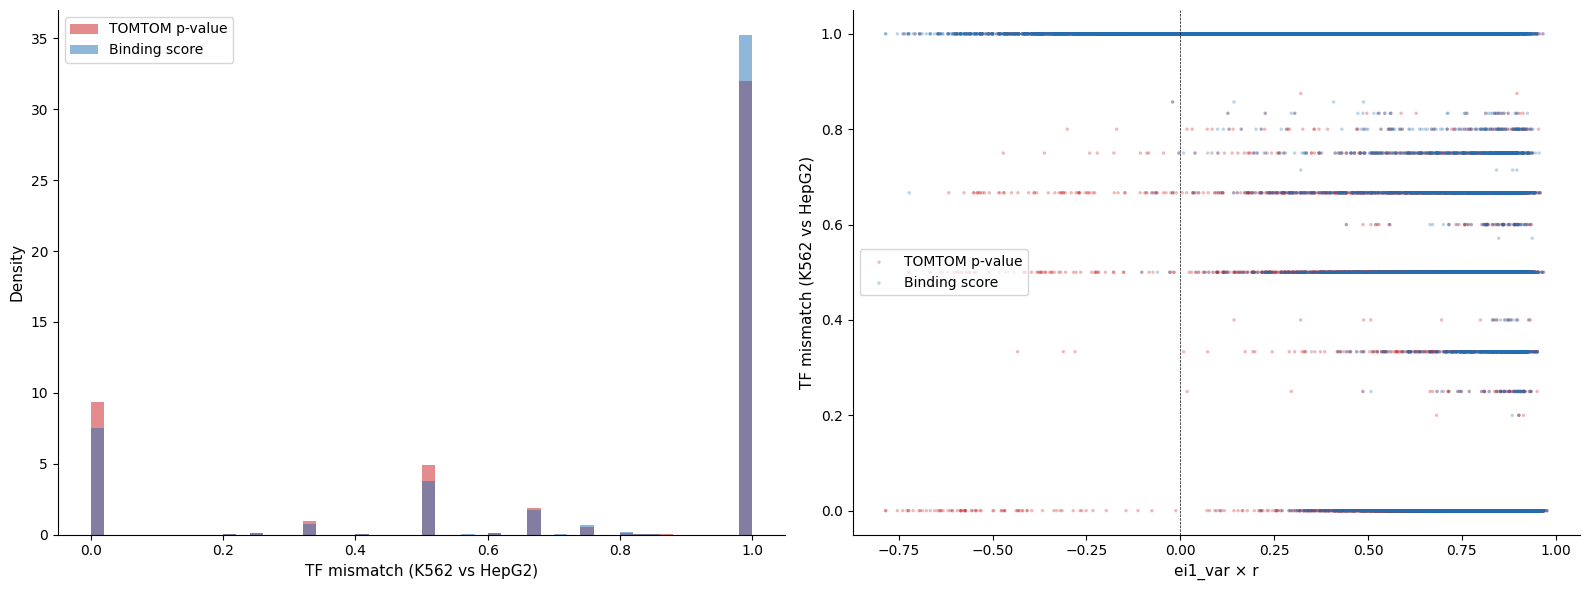

In [6]:
import sys
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import load_encode_expression

# Load RNA-seq
expr = load_encode_expression(['K562', 'HepG2'])
tf_tpm = {}
for ct, edf in expr.items():
    for _, row in edf.iterrows():
        tf_tpm.setdefault(row['gene_name'].upper(), {})[ct] = row['TPM']

cell_types = ['K562', 'HepG2']
score = ei1_var * corrs

def parse_components(tf_name):
    return [p.strip().upper() for p in tf_name.replace('::', ':').split(':') if p.strip()]

def binding_score(tf_name, detecting_ct, s):
    components = parse_components(tf_name)
    log_expr = {}
    for ct in cell_types:
        tpm = max((tf_tpm.get(g, {}).get(ct, 0.0) for g in components), default=0.0)
        log_expr[ct] = np.log1p(tpm)
    w = (1 + np.clip(s, -1, 1)) / 2
    shared = np.mean(list(log_expr.values()))
    others = [log_expr[ct] for ct in cell_types if ct != detecting_ct]
    specific = log_expr[detecting_ct] - (max(others) if others else 0.0)
    return w * shared + (1 - w) * specific

# Re-rank motif hits
motif_hits_ranked = {}
n_changed = 0
n_total = 0

for ct in cell_types:
    ranked = []
    for si in range(n_seqs):
        s = score[si]
        seq_hits = []
        for h in motif_hits[ct][si]:
            candidates = h.get('top_hits', [{'tf': h['tf'], 'pval': h['pval']}])
            scored = []
            for cand in candidates:
                bs = binding_score(cand['tf'], ct, s)
                scored.append({**cand, 'binding_score': bs})
            scored.sort(key=lambda x: x['binding_score'], reverse=True)
            old_tf = h['tf']
            new_tf = scored[0]['tf']
            if old_tf != new_tf:
                n_changed += 1
            n_total += 1
            seq_hits.append({**h, 'top_hits': scored, 'tf': new_tf,
                             'binding_score': scored[0]['binding_score']})
        ranked.append(seq_hits)
    motif_hits_ranked[ct] = ranked

print(f'Re-ranked {n_total} motif hits, {n_changed} changed ({n_changed/max(n_total,1):.1%})')

# Per-sequence mismatch: fraction of TFs not shared between cell types
def compute_mismatch(hits_dict):
    mismatch = np.full(n_seqs, np.nan)
    for si in range(n_seqs):
        tfs_a = set(h['tf'] for h in hits_dict[cell_types[0]][si])
        tfs_b = set(h['tf'] for h in hits_dict[cell_types[1]][si])
        union = tfs_a | tfs_b
        if not union:
            continue
        mismatch[si] = len(tfs_a ^ tfs_b) / len(union)
    return mismatch

mm_pval = compute_mismatch(motif_hits)
mm_bind = compute_mismatch(motif_hits_ranked)
has_data = np.isfinite(mm_pval) & np.isfinite(mm_bind)
idx = np.where(has_data)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: mismatch distribution for both methods
ax1.hist(mm_pval[idx], bins=50, alpha=0.5, color='#cb181d', label='TOMTOM p-value', density=True)
ax1.hist(mm_bind[idx], bins=50, alpha=0.5, color='#2171b5', label='Binding score', density=True)
ax1.set_xlabel('TF mismatch (K562 vs HepG2)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Right: mismatch vs ei1_var x r, two colors for two methods
ax2.scatter(score[idx], mm_pval[idx], s=6, alpha=0.3, c='#cb181d',
            edgecolors='none', rasterized=True, label='TOMTOM p-value')
ax2.scatter(score[idx], mm_bind[idx], s=6, alpha=0.3, c='#2171b5',
            edgecolors='none', rasterized=True, label='Binding score')
ax2.set_xlabel('ei1_var × r', fontsize=11)
ax2.set_ylabel('TF mismatch (K562 vs HepG2)', fontsize=11)
ax2.axvline(0, color='k', lw=0.5, ls='--')
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
score = ei1_var * corrs
hippo_kw = ['TEAD', 'STAT', 'JUN', 'FOS', 'RUNX']

# Per-sequence TF sets using binding-score-ranked hits
seq_tf_sets = []
for i in range(n_seqs):
    tfs_i = set()
    for ct in ['K562', 'HepG2']:
        for h in motif_hits_ranked[ct][i]:
            for alt in h.get('top_hits', []):
                tfs_i.add(alt['tf'])
    seq_tf_sets.append(frozenset(tfs_i))

# Group sequences by their motif syntax
from collections import defaultdict
syntax_seqs = defaultdict(list)
for i in range(n_seqs):
    if seq_tf_sets[i]:  # skip empty
        syntax_seqs[seq_tf_sets[i]].append(i)

# For each syntax: mean score, count, and fraction same-diff
syntaxes, mean_scores, n_seqs_list, frac_sd = [], [], [], []
for syntax, idxs in syntax_seqs.items():
    if len(idxs) < 3:
        continue
    s = score[idxs]
    syntaxes.append(syntax)
    mean_scores.append(np.mean(s))
    n_seqs_list.append(len(idxs))
    frac_sd.append((s < 0).mean())

mean_scores = np.array(mean_scores)
n_seqs_list = np.array(n_seqs_list)
frac_sd = np.array(frac_sd)

# Top same-diff syntaxes (candidates for perturbation)
sd_order = np.argsort(mean_scores)

print('Top 20 same-diff motif syntaxes (lowest score):')
for j in sd_order[:20]:
    tfs_str = ', '.join(sorted(syntaxes[j]))
    has_hippo = any(any(k in tf.upper() for k in hippo_kw) for tf in syntaxes[j])
    marker = ' ** HIPPO' if has_hippo else ''
    print(f'  score={mean_scores[j]:+.3f}  n={n_seqs_list[j]:3d}  frac_sd={frac_sd[j]:.0%}  [{tfs_str}]{marker}')

print(f'\nTop 20 same-same motif syntaxes (highest score):')
for j in sd_order[-20:][::-1]:
    tfs_str = ', '.join(sorted(syntaxes[j]))
    has_hippo = any(any(k in tf.upper() for k in hippo_kw) for tf in syntaxes[j])
    marker = ' ** HIPPO' if has_hippo else ''
    print(f'  score={mean_scores[j]:+.3f}  n={n_seqs_list[j]:3d}  frac_sd={frac_sd[j]:.0%}  [{tfs_str}]{marker}')

# Build focus_tfs from top same-diff syntaxes containing hippo TFs
focus_tfs = set()
hippo_tfs = set()
for j in sd_order[:50]:
    for tf in syntaxes[j]:
        focus_tfs.add(tf)
        if any(k in tf.upper() for k in hippo_kw):
            hippo_tfs.add(tf)
# Also add top same-same
for j in sd_order[-50:]:
    for tf in syntaxes[j]:
        focus_tfs.add(tf)
        if any(k in tf.upper() for k in hippo_kw):
            hippo_tfs.add(tf)

sig_tfs = focus_tfs - hippo_tfs
print(f'\nFocus TFs from top syntaxes: {len(focus_tfs)}')
print(f'  Hippo: {sorted(hippo_tfs)}')
print(f'  Other: {sorted(sig_tfs)}')

Top 20 same-diff motif syntaxes (lowest score):
  score=-0.702  n=  3  frac_sd=100%  [HNF1A, HNF1B, POU6F1, ZBTB47]
  score=-0.520  n=  3  frac_sd=100%  [HNF1A, HNF1B, POU4F2, RXRB, RXRG, Rxra]
  score=-0.480  n= 10  frac_sd=100%  [HNF1A, HNF1B, POU6F1, RXRB, RXRG, Rxra]
  score=-0.440  n=  6  frac_sd=100%  [ATF6, CREB3L1, HNF1A, HNF1B, RXRB, RXRG, Rxra, XBP1, ZBTB47]
  score=-0.420  n=  3  frac_sd=100%  [HNF1A, HNF1B, LHX2]
  score=-0.419  n= 22  frac_sd=100%  [HNF1A, HNF1B, mix-a]
  score=-0.409  n=  4  frac_sd=100%  [HNF1A, HNF1B, PKNOX2, POU6F1, SNAI2, ZEB1]
  score=-0.335  n= 12  frac_sd=92%  [HNF1A, HNF1B, POU4F2]
  score=-0.330  n= 11  frac_sd=100%  [GSC::TBX21, HNF1A, HNF1B]
  score=-0.322  n=  4  frac_sd=100%  [ATF6, CREB3L1, HNF1A, HNF1B, PKNOX2, POU6F1, SNAI2, XBP1, ZEB1]
  score=-0.297  n=  6  frac_sd=100%  [HNF1A, HNF1B, ZSCAN16]
  score=-0.295  n=  8  frac_sd=100%  [ATF6, CREB3L1, HNF1A, HNF1B, POU6F1, RXRB, RXRG, Rxra, XBP1]
  score=-0.290  n= 12  frac_sd=92%  [HNF1A, HN

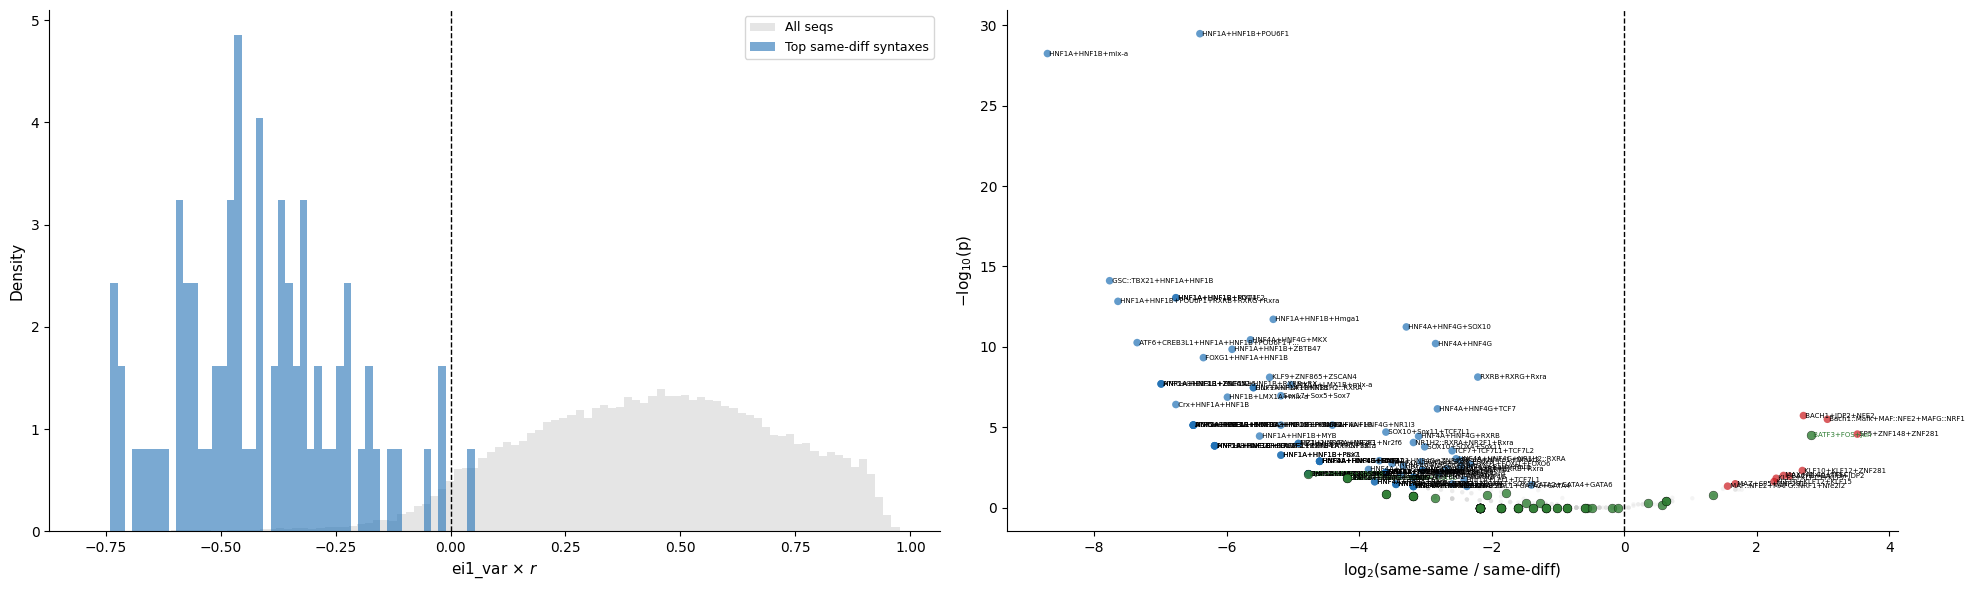

Significant syntaxes (p<0.05): 117

Top 10 same-diff syntaxes:
  score=-0.702  n=  3  [HNF1A, HNF1B, POU6F1, ZBTB47]
  score=-0.520  n=  3  [HNF1A, HNF1B, POU4F2, RXRB, RXRG, Rxra]
  score=-0.480  n= 10  [HNF1A, HNF1B, POU6F1, RXRB, RXRG, Rxra]
  score=-0.440  n=  6  [ATF6, CREB3L1, HNF1A, HNF1B, RXRB, RXRG, Rxra, XBP1, ZBTB47]
  score=-0.420  n=  3  [HNF1A, HNF1B, LHX2]
  score=-0.419  n= 22  [HNF1A, HNF1B, mix-a]
  score=-0.409  n=  4  [HNF1A, HNF1B, PKNOX2, POU6F1, SNAI2, ZEB1]
  score=-0.335  n= 12  [HNF1A, HNF1B, POU4F2]
  score=-0.330  n= 11  [GSC::TBX21, HNF1A, HNF1B]
  score=-0.322  n=  4  [ATF6, CREB3L1, HNF1A, HNF1B, PKNOX2, POU6F1, SNAI2, XBP1, ZEB1]


In [8]:
from scipy.stats import fisher_exact

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Left: score distribution
ax1.hist(score, bins=100, density=True, color='#cccccc', alpha=0.5, label='All seqs')
sd_idxs = []
for j in sd_order[:10]:
    sd_idxs.extend(syntax_seqs[syntaxes[j]])
sd_idxs = np.array(sd_idxs)
ax1.hist(score[sd_idxs], bins=50, density=True, alpha=0.6, color='#2171b5', label='Top same-diff syntaxes')
ax1.axvline(0, color='k', lw=1, ls='--')
ax1.set_xlabel('ei1_var × $r$', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Right: volcano — each dot = a motif syntax
n_total_ss = (score > 0).sum()
n_total_sd = (score < 0).sum()

vlfc, vnlp, vhippo, vsyntax_idx = [], [], [], []
for j in range(len(syntaxes)):
    idxs = syntax_seqs[syntaxes[j]]
    a = sum(1 for i in idxs if score[i] > 0)
    b = sum(1 for i in idxs if score[i] < 0)
    if a + b < 3:
        continue
    lfc = np.log2(((a+1)/(n_total_ss+1)) / ((b+1)/(n_total_sd+1)))
    _, pval = fisher_exact([[a, n_total_ss - a], [b, n_total_sd - b]])
    pval = max(pval, 1e-300)
    vlfc.append(lfc); vnlp.append(-np.log10(pval))
    vhippo.append(any(any(k in tf.upper() for k in hippo_kw) for tf in syntaxes[j]))
    vsyntax_idx.append(j)

vlfc, vnlp, vhippo = np.array(vlfc), np.array(vnlp), np.array(vhippo)
vsig = vnlp > -np.log10(0.05)

ax2.scatter(vlfc[~vsig & ~vhippo], vnlp[~vsig & ~vhippo], s=10, alpha=0.2, c='#cccccc', edgecolors='none')
sig_colors = ['#cb181d' if l > 0 else '#2171b5' for l in vlfc[vsig & ~vhippo]]
ax2.scatter(vlfc[vsig & ~vhippo], vnlp[vsig & ~vhippo], s=30, alpha=0.7, c=sig_colors, edgecolors='none')
ax2.scatter(vlfc[vhippo], vnlp[vhippo], s=40, alpha=0.8, c='#2E7D32', edgecolors='k', lw=0.3, zorder=5)

for i in np.where(vsig)[0]:
    j = vsyntax_idx[i]
    label = '+'.join(sorted(syntaxes[j]))
    if len(label) > 35:
        label = label[:32] + '...'
    c = '#2E7D32' if vhippo[i] else 'black'
    ax2.text(vlfc[i], vnlp[i], ' ' + label, fontsize=5, va='center', color=c)

ax2.axvline(0, color='k', lw=1, ls='--')
ax2.set_xlabel('log$_2$(same-same / same-diff)', fontsize=11)
ax2.set_ylabel('$-$log$_{10}$(p)', fontsize=11)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Significant syntaxes (p<0.05): {vsig.sum()}')
print('\nTop 10 same-diff syntaxes:')
for j in sd_order[:10]:
    tfs_str = ', '.join(sorted(syntaxes[j]))
    has_h = any(any(k in tf.upper() for k in hippo_kw) for tf in syntaxes[j])
    print(f'  score={mean_scores[j]:+.3f}  n={n_seqs_list[j]:3d}  [{tfs_str}]{"  ** HIPPO" if has_h else ""}')

  K562: 58721 genes, median TPM=0.00
  HepG2: 58721 genes, median TPM=0.00


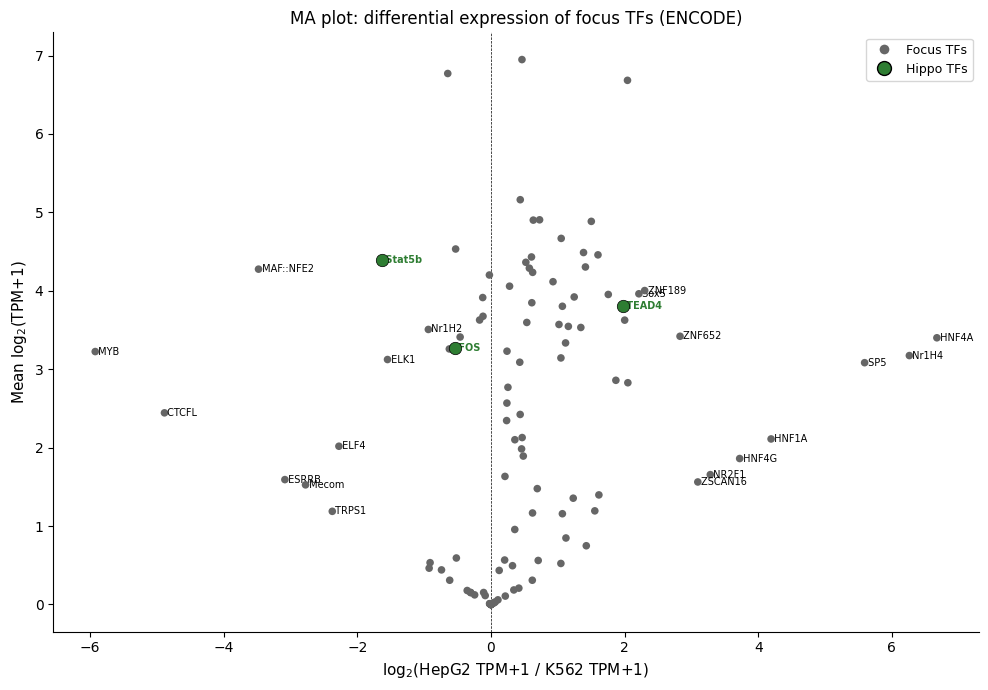

In [9]:
import sys
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import load_encode_expression

expr = load_encode_expression(['K562', 'HepG2'])
tf_tpm = {}
for ct, edf in expr.items():
    for _, row in edf.iterrows():
        tf_tpm.setdefault(row['gene_name'].upper(), {})[ct] = row['TPM']

def get_tpm(tf_name, ct):
    parts = tf_name.replace('::', ':').split(':')
    tpms = [tf_tpm.get(p.strip().upper(), {}).get(ct, 0) for p in parts]
    return max(tpms) if tpms else 0

# Show all focus TFs on MA plot
show_tfs_list = sorted(focus_tfs)
is_hippo_show = np.array([any(k in tf.upper() for k in hippo_kw) for tf in show_tfs_list])

tpm_h = np.array([get_tpm(tf, 'HepG2') for tf in show_tfs_list])
tpm_k = np.array([get_tpm(tf, 'K562') for tf in show_tfs_list])
expr_lfc = np.log2((tpm_h + 1) / (tpm_k + 1))
mean_expr = (np.log2(tpm_h + 1) + np.log2(tpm_k + 1)) / 2

# Label: hippo TFs + top 10 most HepG2-enriched + top 10 most K562-enriched
lfc_order = np.argsort(expr_lfc)
label_idx = set(np.where(is_hippo_show)[0])
label_idx.update(lfc_order[:10])   # most K562
label_idx.update(lfc_order[-10:])  # most HepG2

fig, ax = plt.subplots(figsize=(10, 7))
from matplotlib.lines import Line2D

for i, tf in enumerate(show_tfs_list):
    if is_hippo_show[i]:
        c, s, z = '#2E7D32', 80, 5
    else:
        c, s, z = '#666666', 30, 3
    ax.scatter(expr_lfc[i], mean_expr[i], s=s, c=c,
               edgecolors='k' if is_hippo_show[i] else 'none', lw=0.5, zorder=z)
    if i in label_idx:
        ax.text(expr_lfc[i], mean_expr[i], ' ' + tf, fontsize=7, va='center',
                fontweight='bold' if is_hippo_show[i] else 'normal',
                color='#2E7D32' if is_hippo_show[i] else 'black')

ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('log$_2$(HepG2 TPM+1 / K562 TPM+1)', fontsize=11)
ax.set_ylabel('Mean log$_2$(TPM+1)', fontsize=11)
ax.set_title('MA plot: differential expression of focus TFs (ENCODE)')
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#666666', markersize=8, label='Focus TFs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2E7D32', markeredgecolor='k', markersize=10, label='Hippo TFs'),
], fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
from collections import defaultdict

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

# All sequences with any focus TF — ranked by |EI_1 var x r|
records = []
for i in range(n_seqs):
    overlap = seq_tf_sets[i] & focus_tfs
    if not overlap:
        continue
    k562_hits = motif_hits_ranked['K562'][i]
    hepg2_hits = motif_hits_ranked['HepG2'][i]
    k562_tfs = [h['tf'] for h in k562_hits]
    hepg2_tfs = [h['tf'] for h in hepg2_hits]
    records.append({
        'seq_idx': i,
        'EI_1 var x r': score[i],
        'pred_K562': predictions['K562'][i],
        'pred_HepG2': predictions['HepG2'][i],
        'K562_tfs': ','.join(sorted(set(k562_tfs))) if k562_tfs else '',
        'HepG2_tfs': ','.join(sorted(set(hepg2_tfs))) if hepg2_tfs else '',
        'all_tfs': ','.join(sorted(seq_tf_sets[i])),
    })

focused = pd.DataFrame(records).sort_values('EI_1 var x r', key=abs, ascending=False)
focused = focused.merge(df[['sequence', 'name'] + [f'{ct}_log2FC' for ct in CT]],
                        left_on='seq_idx', right_index=True)

print(f'Focused library: {len(focused)} sequences (ranked by |EI_1 var x r|)')
print(f'  same-same (>0): {(focused["EI_1 var x r"] > 0).sum()}')
print(f'  same-diff (<0): {(focused["EI_1 var x r"] < 0).sum()}')

# Aggregate binding scores per TF, per cell type, split by condition
tf_scores = {ct: defaultdict(list) for ct in cell_types}
tf_scores_ss = {ct: defaultdict(list) for ct in cell_types}
tf_scores_sd = {ct: defaultdict(list) for ct in cell_types}
for ct in cell_types:
    for si in range(n_seqs):
        for h in motif_hits_ranked[ct][si]:
            tf_scores[ct][h['tf']].append(h['binding_score'])
            if score[si] > 0:
                tf_scores_ss[ct][h['tf']].append(h['binding_score'])
            else:
                tf_scores_sd[ct][h['tf']].append(h['binding_score'])

n_hits_ss = {ct: sum(len(v) for v in tf_scores_ss[ct].values()) for ct in cell_types}
n_hits_sd = {ct: sum(len(v) for v in tf_scores_sd[ct].values()) for ct in cell_types}

def print_top5_score(scores_dict, label):
    print(f'\n{label}:')
    for ct in cell_types:
        ranked = sorted(scores_dict[ct].items(),
                        key=lambda x: np.mean(x[1]), reverse=True)[:5]
        print(f'  {ct}:')
        for tf, sl in ranked:
            print(f'    {tf:20s}  bind_score={np.mean(sl):.2f}  (n={len(sl)})')

def print_top5_enrichment(scores_cond, label, ascending=False):
    print(f'\n{label}:')
    for ct in cell_types:
        enrichments = []
        for tf in set(list(tf_scores_sd[ct].keys()) + list(tf_scores_ss[ct].keys())):
            n_sd = len(tf_scores_sd[ct].get(tf, []))
            n_ss = len(tf_scores_ss[ct].get(tf, []))
            if n_sd + n_ss < 3:
                continue
            frac_sd = (n_sd + 1) / (n_hits_sd[ct] + 1)
            frac_ss = (n_ss + 1) / (n_hits_ss[ct] + 1)
            lfc = np.log2(frac_sd / frac_ss)  # positive = enriched in same-diff
            bs = np.mean(scores_cond[ct][tf]) if tf in scores_cond[ct] else 0
            n_cond = len(scores_cond[ct].get(tf, []))
            enrichments.append((tf, lfc, bs, n_sd, n_ss, n_cond))
        enrichments.sort(key=lambda x: x[1], reverse=not ascending)
        print(f'  {ct}:')
        for tf, lfc, bs, nsd, nss, nc in enrichments[:5]:
            print(f'    {tf:20s}  enrichment={lfc:+.2f}  bind_score={bs:.2f}  (n_sd={nsd}, n_ss={nss})')

print_top5_score(tf_scores, 'Top 5 TFs by binding score (all sequences)')
print_top5_enrichment(tf_scores_ss, 'Top 5 TFs enriched in same-same (EI_1 var x r > 0)', ascending=True)
print_top5_enrichment(tf_scores_sd, 'Top 5 TFs enriched in same-diff (EI_1 var x r < 0)', ascending=False)

show_cols = ['EI_1 var x r', 'K562_tfs', 'HepG2_tfs']
print(f'\nTop 10 same-same sequences:')
print(focused[focused['EI_1 var x r'] > 0][show_cols].head(10).to_string())
print(f'\nTop 10 same-diff sequences:')
print(focused[focused['EI_1 var x r'] < 0].sort_values('EI_1 var x r')[show_cols].head(10).to_string())

Focused library: 25626 sequences (ranked by |EI_1 var x r|)
  same-same (>0): 23386
  same-diff (<0): 2240

Top 5 TFs by binding score (all sequences):
  K562:
    ATF4                  bind_score=4.29  (n=653)
    MAZ                   bind_score=3.93  (n=1479)
    Hmga1                 bind_score=3.55  (n=24)
    XBP1                  bind_score=3.52  (n=99)
    ZNF146                bind_score=3.50  (n=4)
  HepG2:
    ATF4                  bind_score=4.42  (n=504)
    MAZ                   bind_score=4.12  (n=942)
    SP3                   bind_score=3.73  (n=344)
    XBP1                  bind_score=3.52  (n=229)
    HLF                   bind_score=3.34  (n=123)

Top 5 TFs enriched in same-same (EI_1 var x r > 0):
  K562:
    SP3                   enrichment=-3.46  bind_score=3.48  (n_sd=0, n_ss=471)
    NFYC                  enrichment=-3.25  bind_score=2.63  (n_sd=1, n_ss=817)
    ZNF281                enrichment=-3.20  bind_score=1.94  (n_sd=3, n_ss=1576)
    NFYB              

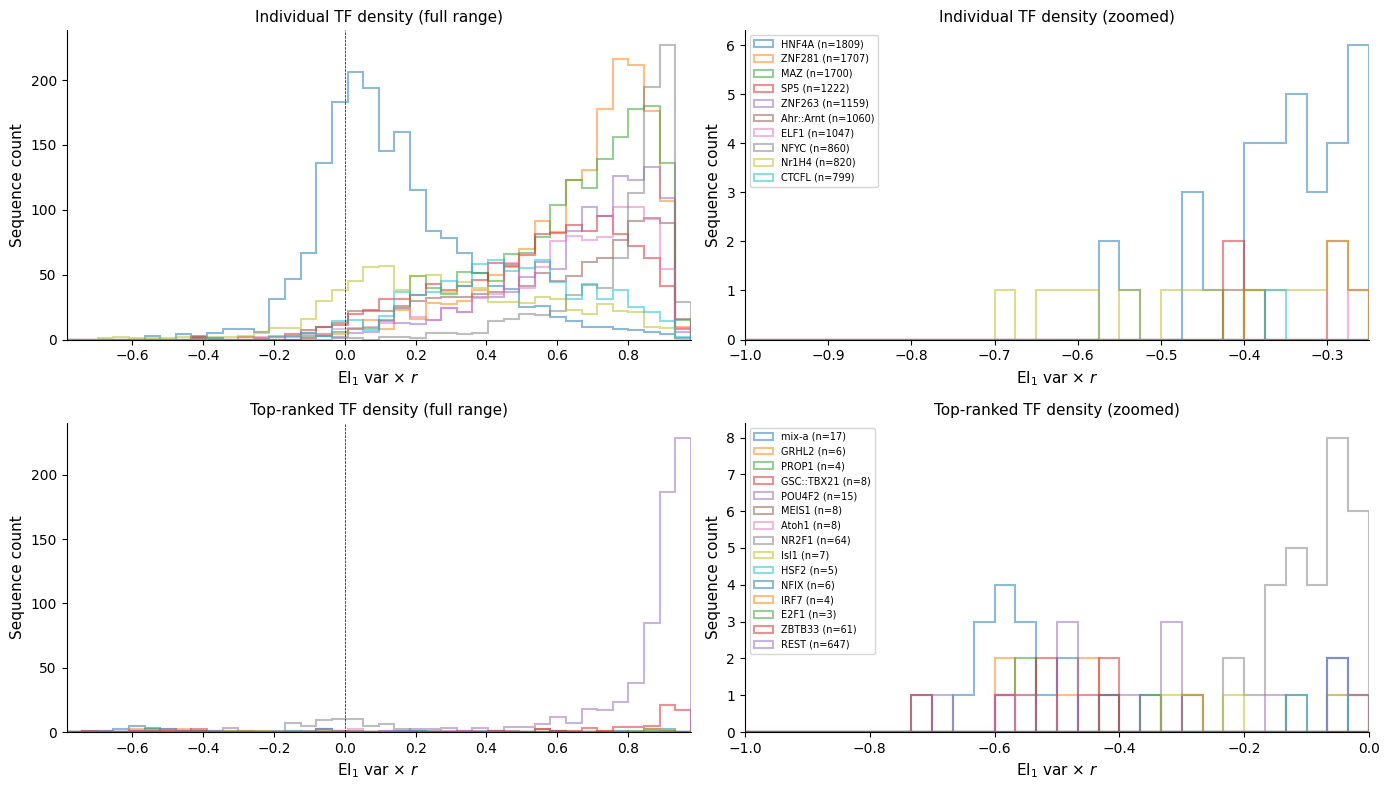

In [37]:
# assess Top 10 same-same and same-diff seq results. TF density over EI_1 var x r

def get_tfs(row):
    tfs = set()
    for col in ['K562_tfs', 'HepG2_tfs']:
        if row[col]:
            for tf in row[col].split(','):
                tfs.add(tf.strip())
    return tfs

def get_top_tf(row):
    """Top-ranked (first) TF per cell type."""
    tfs = []
    for col in ['K562_tfs', 'HepG2_tfs']:
        if row[col]:
            tfs.append(row[col].split(',')[0].strip())
    return tfs

from collections import Counter, defaultdict

# --- Individual TFs: top 10 by frequency ---
tf_counts = Counter()
for _, row in focused.iterrows():
    for tf in get_tfs(row):
        tf_counts[tf] += 1
top_tfs = [tf for tf, _ in tf_counts.most_common(10)]

# --- Motif syntax: single TF names, ranked by extreme mean score ---
tf_scores = defaultdict(list)
for _, row in focused.iterrows():
    for tf in get_top_tf(row):
        tf_scores[tf].append(row['EI_1 var x r'])

tf_mean = {tf: np.mean(v) for tf, v in tf_scores.items() if len(v) >= 3}
sorted_by_score = sorted(tf_mean.items(), key=lambda x: x[1])
sorted_by_neutral = sorted(tf_mean.items(), key=lambda x: abs(x[1]))
top_syntax_tfs = ([tf for tf, _ in sorted_by_score[:5]]
                + [tf for tf, _ in sorted_by_neutral[:5]]
                + [tf for tf, _ in sorted_by_score[-5:]])
# deduplicate while preserving order
seen = set()
top_syntax_tfs = [tf for tf in top_syntax_tfs if not (tf in seen or seen.add(tf))]

score_min, score_max = focused['EI_1 var x r'].min(), focused['EI_1 var x r'].max()
bins_full = np.linspace(score_min, score_max, 41)
bins_zoom_tf = np.linspace(-1, -0.25, 31)
bins_zoom_syn = np.linspace(-1, 0, 31)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top row: individual TF by frequency
for col, (bins, xlim) in enumerate([(bins_full, (score_min, score_max)), (bins_zoom_tf, (-1, -0.25))]):
    ax = axes[0, col]
    for tf in top_tfs:
        vals = [row['EI_1 var x r'] for _, row in focused.iterrows() if tf in get_tfs(row)]
        ax.hist(vals, bins=bins, alpha=0.5, label=f'{tf} (n={len(vals)})', histtype='step', linewidth=1.5)
    ax.set_xlabel('EI$_1$ var $\\times$ $r$', fontsize=11)
    ax.set_ylabel('Sequence count', fontsize=11)
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.set_xlim(xlim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0, 0].set_title('Individual TF density (full range)', fontsize=11)
axes[0, 1].set_title('Individual TF density (zoomed)', fontsize=11)
axes[0, 1].legend(fontsize=7, loc='upper left')

# Bottom row: motif syntax — single TF names ranked by extreme + neutral score
for col, (bins, xlim) in enumerate([(bins_full, (score_min, score_max)), (bins_zoom_syn, (-1, 0))]):
    ax = axes[1, col]
    for tf in top_syntax_tfs:
        vals = np.array(tf_scores[tf])
        ax.hist(vals, bins=bins, alpha=0.5, label=f'{tf} (n={len(vals)})', histtype='step', linewidth=1.5)
    ax.set_xlabel('EI$_1$ var $\\times$ $r$', fontsize=11)
    ax.set_ylabel('Sequence count', fontsize=11)
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.set_xlim(xlim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[1, 0].set_title('Top-ranked TF density (full range)', fontsize=11)
axes[1, 1].set_title('Top-ranked TF density (zoomed)', fontsize=11)
axes[1, 1].legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

In [12]:
## Final focus, pick n from Top 10 same-same sequences and Top 10 same-diff sequences to study save key seqs in next cell

top_n = 0



In [13]:
save_path = os.path.join(REPO, 'genomic_targets', 'library', 'hippo_focused_library.pkl')

idxs = focused.seq_idx.values
focused_motif_hits = {
    ct: [motif_hits_ranked[ct][i] for i in idxs]
    for ct in ['K562', 'HepG2']
}
focused_eigen = [cached['eigen_results'][i] for i in idxs]

save_data = {
    'df': focused,
    'motif_hits': focused_motif_hits,
    'eigen_results': focused_eigen,
    'focus_tfs': sorted(focus_tfs),
    'attr_npz_path': os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'),
}

with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f'Saved to {save_path}')
print(f'  {len(focused)} sequences, ranked by |EI_1 var x r|')
print(f'  Keys: {list(save_data.keys())}')

Saved to /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/library/hippo_focused_library.pkl
  25626 sequences, ranked by |EI_1 var x r|
  Keys: ['df', 'motif_hits', 'eigen_results', 'focus_tfs', 'attr_npz_path']
